# 02 · Model evaluation: walk-forward 2025-26

**Protocol.** For every gameweek k = 5…38 of 2025-26, each model is trained on all earlier seasons
plus 2025-26 GWs < k and predicts GW k (34 refits, expanding window). Models:

| | Model | Notes |
|---|---|---|
| B0 | rolling form | `pts_r5` → `pts_season_avg` → 0 |
| B1 | Ridge | median impute + missing indicators → standardise → `RidgeCV`, position one-hot |
| M1 | LightGBM, L2 | the model the optimizer uses (expected points) |
| M2 | LightGBM, L1 | comparison only (predicts the median) |

LightGBM early-stops on the last 3 GWs of each training window, then refits on the whole window.
Predictions are per fixture and scored per **player-gameweek** (summed over a DGW's fixtures).
**Regulars** = lagged `minutes_r3 >= 45`. The CI is a block bootstrap: 1,000 resamples of whole
gameweeks.

Produced by `python -m fPLense.pipeline --evaluate`, which writes `data/published/metrics.json`
and the per-row predictions in `data/eval/` (gitignored).

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from fPLense import config
from fPLense.models import evaluate as ev

sns.set_theme(style="whitegrid", context="notebook")
metrics = json.loads(config.METRICS_PATH.read_text(encoding="utf-8"))
wf = pd.read_parquet(config.EVAL_DIR / "walk_forward_2025_26.parquet")
gw = ev.to_player_gw(wf)
regs = gw[gw.regular]
print(f"{metrics['walk_forward']['n_gameweeks']} gameweeks, {len(gw):,} player-GWs "
      f"({len(regs):,} regulars); generated {metrics['generated_at']}")

34 gameweeks, 26,491 player-GWs (7,365 regulars); generated 2026-10-08T08:19:05+00:00


## 1. Headline metrics

In [2]:
table = ev.metrics_table(metrics["walk_forward"])
table

,subset,model,n,MAE,RMSE,MAE gain vs B0,Spearman/GW,Top-20 prec./GW
0,regulars,B0 rolling form,7365,2.535,3.346,-,0.174,0.166
1,regulars,B1 Ridge,7365,2.295,3.051,"+9.5% [+8.5, +10.4]",0.299,0.235
2,regulars,M1 LightGBM (L2),7365,2.246,3.030,"+11.4% [+10.2, +12.6]",0.323,0.225
3,regulars,M2 LightGBM (L1),7365,2.068,3.279,"+18.4% [+16.7, +20.0]",0.317,0.212
4,all,B0 rolling form,26491,1.037,2.098,-,0.722,0.140
5,all,B1 Ridge,26491,1.045,1.936,"-0.8% [-1.9, +0.2]",0.707,0.212
6,all,M1 LightGBM (L2),26491,0.966,1.909,"+6.8% [+5.7, +7.9]",0.726,0.201
7,all,M2 LightGBM (L1),26491,0.840,2.056,"+19.0% [+17.6, +20.2]",0.725,0.181


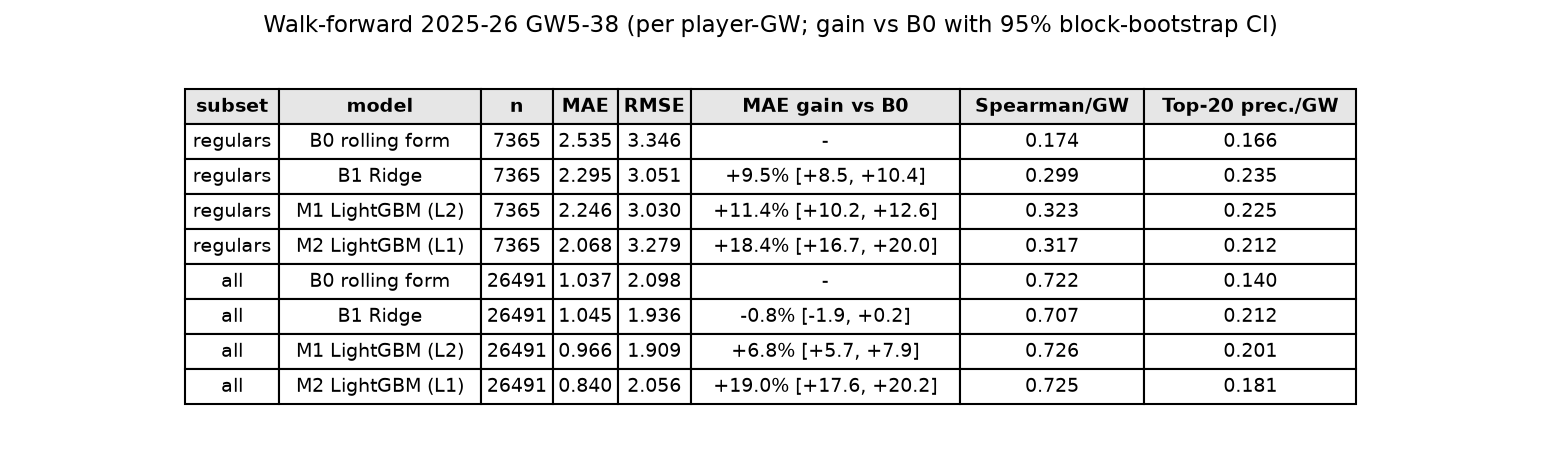

In [3]:
display(Image(filename=str(config.DOCS_IMG_DIR / "metrics_table.png")))

**Takeaway.** On regulars (7,365 player-GWs over 34 gameweeks), LightGBM L2 cuts MAE from 2.535 (B0) to 2.246: **−11.4%, 95% CI [10.2%, 12.6%]**, the resume's headline number. Ridge already gets −9.5% [8.5, 10.4], so most of the gain comes from using many features at all; the trees add about 2 percentage points more. Spearman per GW nearly doubles (0.17 → 0.32). On top-20 precision Ridge is slightly ahead (0.235 vs 0.225), so LightGBM is not better on every metric. M2 (L1) has the lowest MAE (−18.4%) but the worst RMSE among the learned models (3.28 vs 3.03): it predicts the median and under-rates hauls. The optimizer needs expected points, so M1 (L2) stays the production model and the claim. On all rows, zero-minute players make every model look good (Spearman ≈ 0.72), which is why regulars are the headline subset.

## 2. MAE by gameweek (regulars)

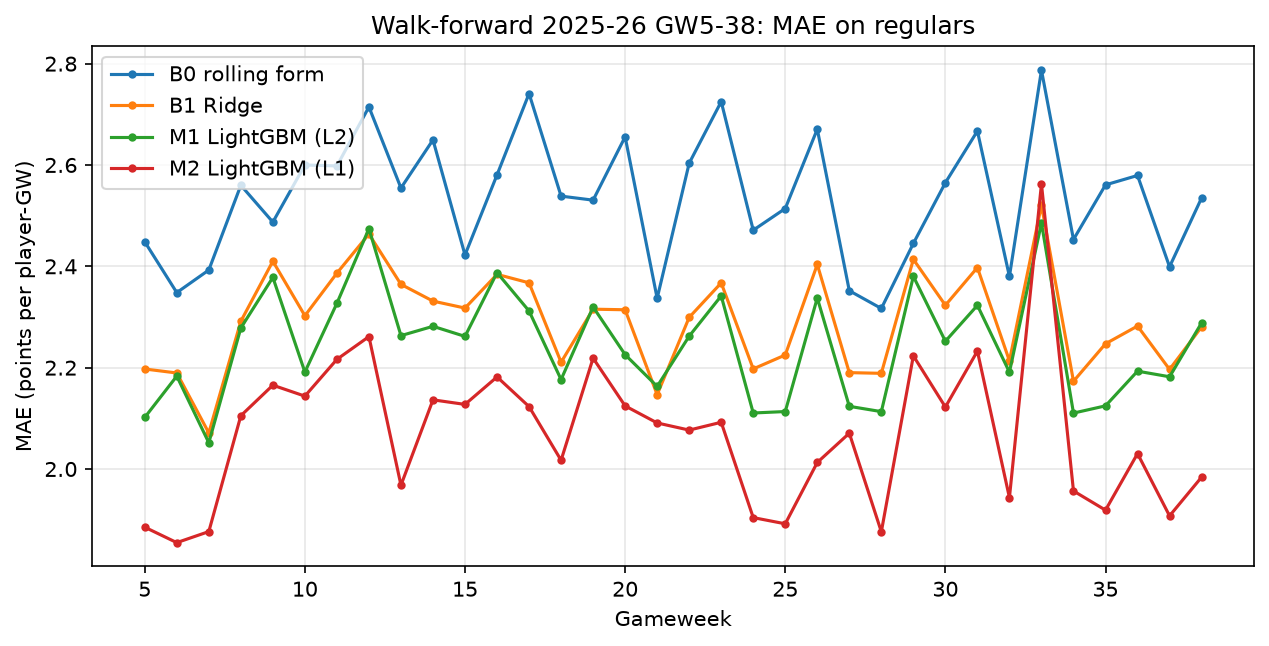

GWs where LightGBM (L2) beats B0: 34 of 34


,b0,ridge,lgbm,lgbm_l1
mean,2.535,2.294,2.244,2.068
min,2.317,2.071,2.052,1.855
max,2.787,2.521,2.486,2.563


In [4]:
display(Image(filename=str(config.DOCS_IMG_DIR / "mae_by_gw.png")))
per = pd.DataFrame({c.removeprefix("pred_"): ev.per_gw(regs, c).set_index("gw")["mae"]
                    for c in ev.pred_columns(regs)})
print("GWs where LightGBM (L2) beats B0:", int((per.lgbm < per.b0).sum()), "of", len(per))
per.describe().loc[["mean", "min", "max"]].round(3)

**Takeaway.** LightGBM L2 beats B0 in **all 34 of 34** gameweeks; per-GW MAE ranges from 2.05 to 2.49 (B0: 2.32–2.79). The gain is not driven by a few easy gameweeks, which is also why the block-bootstrap CI is tight.

## 3. Calibration (regulars)

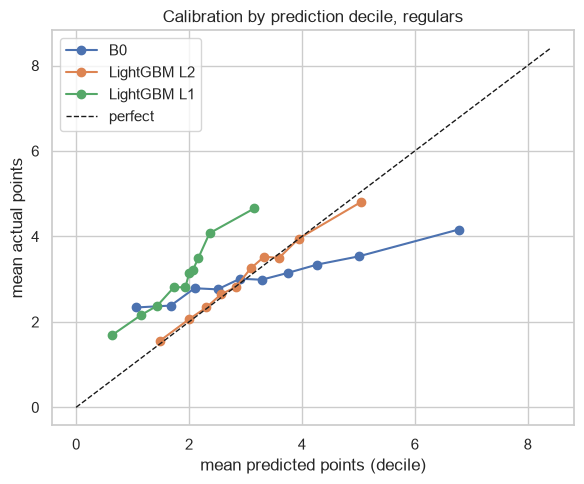

,decile,n,mean_pred,mean_actual
0,1,737,1.48,1.56
1,2,736,2.00,2.06
2,3,737,2.31,2.34
3,4,736,2.57,2.65
4,5,737,2.83,2.81
5,6,736,3.09,3.25
6,7,736,3.33,3.53
7,8,737,3.59,3.50
8,9,736,3.94,3.95
9,10,737,5.05,4.80


In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
for col, label in [("pred_b0", "B0"), ("pred_lgbm", "LightGBM L2"), ("pred_lgbm_l1", "LightGBM L1")]:
    cal = ev.calibration(regs, col)
    ax.plot(cal.mean_pred, cal.mean_actual, marker="o", label=label)
lim = [0, max(regs.pred_b0.quantile(0.99), 8)]
ax.plot(lim, lim, "k--", lw=1, label="perfect")
ax.set_xlabel("mean predicted points (decile)")
ax.set_ylabel("mean actual points")
ax.set_title("Calibration by prediction decile, regulars")
ax.legend()
plt.tight_layout()
plt.show()
ev.calibration(regs, "pred_lgbm").round(2)

**Takeaway.** LightGBM L2 is well calibrated: deciles 1–5 sit within 0.08 points of the diagonal. The top decile is slightly over-predicted (5.05 predicted vs 4.80 actual), and deciles 6–7 slightly under-predicted (by about 0.2). Good enough to feed expected points into the optimizer; the top-decile optimism is worth remembering when the ILP chases premium captains.

## 4. By position (regulars)

In [6]:
pos = pd.DataFrame({
    p: {f"{m} MAE": v["mae"] for m, v in d.items()} | {"n": d["b0"]["n"],
        "LGBM gain %": d["lgbm"]["mae_gain_pct"]}
    for p, d in metrics["walk_forward"]["regulars_by_position"].items()
}).T.loc[["GK", "DEF", "MID", "FWD"]]
pos.round(3)

,b0 MAE,ridge MAE,lgbm MAE,lgbm_l1 MAE,n,LGBM gain %
GK,2.285,2.055,2.050,1.833,671.0,10.299
DEF,2.633,2.373,2.320,2.199,2837.0,11.881
MID,2.451,2.216,2.157,1.977,3114.0,11.983
FWD,2.743,2.540,2.513,2.165,743.0,8.397


**Takeaway.** The gain holds in every position: DEF −11.9%, MID −12.0%, GK −10.3%, FWD −8.4%. Forwards are hardest (MAE 2.51; few rows and the fattest haul tail). L1 helps forwards most on MAE, as expected for the most skewed position.

## 5. Second view: 2024-25 season holdout

One fit on 2016-17 … 2023-24, scored on all of 2024-25 GW5+ (no in-season refits).

In [7]:
ev.metrics_table(metrics["holdout"])

,subset,model,n,MAE,RMSE,MAE gain vs B0,Spearman/GW,Top-20 prec./GW
0,regulars,B0 rolling form,7420,2.363,3.235,-,0.242,0.206
1,regulars,B1 Ridge,7420,2.138,2.969,"+9.5% [+8.3, +10.8]",0.346,0.276
2,regulars,M1 LightGBM (L2),7420,2.112,2.959,"+10.6% [+9.2, +12.1]",0.360,0.262
3,regulars,M2 LightGBM (L1),7420,1.925,3.218,"+18.6% [+16.9, +20.1]",0.354,0.212
4,all,B0 rolling form,24369,1.043,2.083,-,0.699,0.178
5,all,B1 Ridge,24369,1.050,1.933,"-0.7% [-1.9, +0.5]",0.690,0.247
6,all,M1 LightGBM (L2),24369,0.982,1.914,"+5.9% [+4.9, +6.8]",0.711,0.235
7,all,M2 LightGBM (L1),24369,0.848,2.065,"+18.7% [+17.9, +19.7]",0.715,0.197


**Takeaway.** The 2024-25 holdout (one fit, no in-season refits) tells the same story: LightGBM L2 −10.6% [9.2, 12.1], Ridge −9.5%, L1 −18.6%. So the result isn't specific to 2025-26 or to walk-forward refitting.

## 6. Ablation (LightGBM L2, walk-forward 2025-26, every 2nd GW)

Each step adds a block: (i) player form, minutes, market and raw attacking/defensive stats;
(ii) + fixture/opponent form (FDR, home, team/opponent goals, DGW); (iii) + xG features;
(iv) + bookmaker odds and Elo (the full set). The last row is (iv) trained on 2022-23+ only.

In [8]:
abl = metrics["ablation"]
rows = []
for name, m in abl.items():
    if not isinstance(m, dict) or "regulars_mae" not in m:
        continue
    lo, hi = m["regulars_mae_gain_ci95"]
    rows.append({"config": name, "features": abl["feature_counts"].get(name, len(config.FEATURES)), "regulars MAE": m["regulars_mae"],
                 "gain vs B0 %": m["regulars_mae_gain_pct"], "CI lo": lo, "CI hi": hi,
                 "Spearman/GW": m["regulars_spearman_per_gw"], "all-rows MAE": m["all_mae"]})
abl_table = pd.DataFrame(rows).set_index("config")
abl_table.round(3)

,features,regulars MAE,gain vs B0 %,CI lo,CI hi,Spearman/GW,all-rows MAE
config,,,,,,,
i_form,26,2.294,9.192,7.319,10.865,0.309,0.981
ii_fixture,32,2.260,10.554,8.523,12.282,0.331,0.968
iii_xg,38,2.253,10.800,8.937,12.506,0.339,0.968
iv_odds_elo,43,2.250,10.915,8.907,12.681,0.342,0.965
iv_odds_elo_2022on,43,2.251,10.890,9.106,12.553,0.336,0.967


In [9]:
by_pos = pd.DataFrame({k: v["regulars_mae_by_position"] for k, v in abl.items()
                       if isinstance(v, dict) and "regulars_mae_by_position" in v}).T
by_pos = by_pos[["GK", "DEF", "MID", "FWD"]]
delta = (by_pos.loc["iv_odds_elo"] - by_pos.loc["iii_xg"]).rename("(iv) − (iii)")
pd.concat([by_pos, delta.to_frame().T]).round(3)

,GK,DEF,MID,FWD
i_form,2.144,2.367,2.182,2.620
ii_fixture,2.106,2.329,2.153,2.580
iii_xg,2.068,2.316,2.152,2.606
iv_odds_elo,2.093,2.308,2.147,2.605
iv_odds_elo_2022on,2.077,2.309,2.155,2.587
(iv) − (iii),0.025,-0.007,-0.006,-0.001


**Takeaway.** Most of the gain comes from the first two blocks: form/minutes/market alone gives −9.2%, and fixture/opponent form adds about 1.4 percentage points (MAE 2.294 → 2.260). xG adds a little (2.253). **Odds/Elo add almost nothing measurable on top** (2.253 → 2.250 overall; by position DEF −0.007, MID −0.006, FWD −0.001, GK +0.025). That's well within fold noise: once FDR, team/opponent goal form and xG are in, the market signal is largely redundant for this model. (The EDA showed implied goals are strongly related to points on their own.) Training only on the xG era (2022-23+) is no better than all 10 seasons (2.251 vs 2.250): the older seasons neither help nor hurt. Ablation runs use every 2nd GW, so compare them with each other, not with the step-1 headline.

## Conclusion

- **Headline (resume): LightGBM cuts next-gameweek MAE on regulars by 11.4% vs the rolling-form baseline (95% CI 10.2–12.6%), walk-forward over 2025-26 GW5–38.** It beats the baseline in all 34 gameweeks and in every position, and the 2024-25 holdout agrees (−10.6%).
- Ridge is a strong second (−9.5%); LightGBM's advantage over it is real but small, and Ridge edges it on top-20 precision.
- L1 wins on MAE but loses on RMSE; L2 stays in production because the optimizer needs expected values.
- Odds/Elo features did not measurably improve MAE over fixture form + xG. They stay in the model (no harm, forward-looking for the live path, where team form is short early in a season), but the claim is about the full system, not about the odds.